## Problem Overview

**Scenario**: A machine claims the mean weight of packaged items is 50g. A quality-check sample of 8 measurements is collected.

**Objective**: Test whether the sample provides evidence that the mean weight differs from 50g using a two-tailed test at α = 0.05.

**Data**: Eight weight measurements (n = 8): 52, 49, 51, 48, 53, 47, 50, 54 grams

## Prompt Used for LLM Assistance

**Prompt**:
> "I have eight observations representing product weights from a quality control sample. I want to verify if the true average weight differs from a target value of 50 using appropriate statistical methodology. Perform a two-sided hypothesis test at a 5% significance level. Show the complete implementation including: (1) hypothesis formulation, (2) calculation of sample statistics, (3) test statistic derivation with formulas, (4) p-value computation, (5) decision rule application, and (6) practical interpretation. Include both manual calculations and Python implementation."

**Reason for This Prompt**:
- **Avoids Direct Copying**: Rephrases the problem in generic statistical terms without copying the exact question wording
- **Comprehensive Coverage**: Explicitly requests all required components (implementation, explanation, formulas)
- **Educational Focus**: Frames it as a learning exercise requiring step-by-step derivation
- **Professional Context**: Uses quality control terminology to maintain real-world relevance
- **Dual Approach**: Requests both mathematical derivation and code implementation for complete understanding
- **Clear Structure**: Lists specific requirements (1-6) ensuring nothing is missed

### Why We Import These Libraries:

**Statistical Computing & Data Manipulation:**
- `numpy`: Fundamental package for numerical operations - handles arrays, mathematical functions, and statistical calculations efficiently
- `pandas`: While not heavily used here, it's standard for data handling in statistical analysis

**Statistical Functions:**
- `scipy.stats`: Core statistical library providing:
  - `ttest_1samp`: Automated one-sample t-test implementation for verification
  - `shapiro`: Shapiro-Wilk normality test to validate assumptions
  - Distribution functions (CDF, PPF) for p-value and critical value calculations

**Visualization:**
- `matplotlib.pyplot`: Foundation for creating plots and charts
- `seaborn`: Built on matplotlib, provides statistical plotting with better aesthetics

**Configuration:**
- `warnings.filterwarnings("ignore")`: Suppresses non-critical warnings for cleaner output
- `sns.set_style("whitegrid")`: Professional appearance with grid for readability
- `plt.rcParams["figure.dpi"] = 100`: Sets resolution for clear, publication-quality figures

**How This Supports Our Analysis:**
All these tools work together to enable: (1) manual calculations with numpy, (2) verification with scipy, (3) assumption checking, and (4) professional visualization of results.

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, shapiro
import warnings

warnings.filterwarnings("ignore")

# Set visualization defaults
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## Step 1: Data Preparation and Exploratory Analysis

### Why This Step is Critical:

Before performing any statistical test, we must properly organize our data and set parameters. This step establishes:

1. **Data Structure**: Converting raw measurements to numpy array for efficient numerical operations
2. **Parameter Definition**: Explicitly stating the hypothesized mean (μ₀ = 50g) we're testing against
3. **Significance Level**: Setting α = 0.05 (standard in scientific research, representing 5% Type I error risk)

### How We Implement This:

- `np.array([...])`: Creates a numpy array from the 8 weight measurements, enabling vectorized operations
- `mu_0 = 50`: The machine's claimed mean weight (our null hypothesis value)
- `alpha = 0.05`: Conventional threshold for statistical significance (95% confidence level)
- Print statements verify data entry before analysis begins

This foundational step ensures we have clean, properly formatted data and clearly defined testing parameters before proceeding with statistical calculations.

In [2]:
# Sample data: weight measurements in grams
weights = np.array([52, 49, 51, 48, 53, 47, 50, 54])

# Hypothesized population mean
mu_0 = 50

# Significance level
alpha = 0.05

print("="*60)
print("QUALITY CONTROL WEIGHT ANALYSIS")
print("="*60)
print(f"\nSample Data: {weights}")
print(f"Sample Size (n): {len(weights)}")
print(f"Hypothesized Mean (μ₀): {mu_0} g")
print(f"Significance Level (α): {alpha}")

QUALITY CONTROL WEIGHT ANALYSIS

Sample Data: [52 49 51 48 53 47 50 54]
Sample Size (n): 8
Hypothesized Mean (μ₀): 50 g
Significance Level (α): 0.05


## Step 2: Hypothesis Formulation

We are conducting a **two-tailed one-sample t-test**.

**Hypotheses**:
- **Null Hypothesis (H₀)**: μ = 50 (The true mean weight equals 50g)
- **Alternative Hypothesis (H₁)**: μ ≠ 50 (The true mean weight differs from 50g)

**Test Selection Rationale**:
- Small sample size (n = 8 < 30)
- Population standard deviation unknown
- Testing against a specific hypothesized value
- Two-tailed test (interested in differences in either direction)

→ **One-sample t-test is appropriate**

## Step 3: Calculate Sample Statistics (Manual Calculation)

### Why Manual Calculation Matters:

While libraries can compute these automatically, manual calculation demonstrates:
1. **Understanding of Statistical Theory**: Shows we know the mathematical foundations
2. **Transparency**: Makes every step of the process explicit and verifiable
3. **Learning Objective**: Required for exams and proves conceptual mastery
4. **Error Detection**: Helps identify data issues or calculation mistakes

### How We Calculate Each Statistic:

**Sample Mean (x̄)**: Average of all observations - our best estimate of the population mean

**Sample Variance (s²)**: Uses (n-1) denominator (Bessel's correction) for unbiased estimation when estimating population variance from sample

**Standard Deviation (s)**: Square root of variance, expressed in original units (grams) for interpretability

**Standard Error (SE)**: Quantifies uncertainty in our sample mean estimate - smaller SE means more precise estimate

**t-Statistic**: Standardizes the difference between sample mean and hypothesized mean by dividing by SE - tells us "how many standard errors away" our sample mean is from μ₀

**Degrees of Freedom (df)**: n-1 because we lose one degree of freedom estimating the mean

### Formulas:

**Sample Mean**:
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

**Sample Variance**:
$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

**Sample Standard Deviation**:
$$s = \sqrt{s^2}$$

**Standard Error of the Mean**:
$$SE = \frac{s}{\sqrt{n}}$$

**t-Statistic**:
$$t = \frac{\bar{x} - \mu_0}{SE} = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

**Degrees of Freedom**:
$$df = n - 1$$

In [8]:
# Manual calculation of sample statistics
n = len(weights)

# Sample mean
sample_mean = np.sum(weights) / n

# Sample variance (using n-1 for unbiased estimator)
deviations_squared = (weights - sample_mean) ** 2
sample_variance = np.sum(deviations_squared) / (n - 1)

# Sample standard deviation
sample_std = np.sqrt(sample_variance)

# Standard error of the mean
standard_error = sample_std / np.sqrt(n)

# t-statistic
t_statistic = (sample_mean - mu_0) / standard_error

# Degrees of freedom
df = n - 1

print("\n" + "="*60)
print("MANUAL CALCULATIONS")
print("="*60)
print(f"\n1. Sample Mean (x̄):")
print(f"   x̄ = Σxᵢ/n = {np.sum(weights)}/{n} = {sample_mean:.4f} g")

print(f"\n2. Sample Variance (s²):")
print(f"   s² = Σ(xᵢ - x̄)²/(n-1) = {np.sum(deviations_squared):.4f}/{n-1}")
print(f"   s² = {sample_variance:.4f}")

print(f"\n3. Sample Standard Deviation (s):")
print(f"   s = √s² = √{sample_variance:.4f} = {sample_std:.4f} g")

print(f"\n4. Standard Error (SE):")
print(f"   SE = s/√n = {sample_std:.4f}/√{n} = {standard_error:.4f} g")

print(f"\n5. t-Statistic:")
print(f"   t = (x̄ - μ₀)/SE = ({sample_mean:.4f} - {mu_0})/{standard_error:.4f}")
print(f"   t = {t_statistic:.4f}")

print(f"\n6. Degrees of Freedom:")
print(f"   df = n - 1 = {n} - 1 = {df}")


MANUAL CALCULATIONS

1. Sample Mean (x̄):
   x̄ = Σxᵢ/n = 404/8 = 50.5000 g

2. Sample Variance (s²):
   s² = Σ(xᵢ - x̄)²/(n-1) = 42.0000/7
   s² = 6.0000

3. Sample Standard Deviation (s):
   s = √s² = √6.0000 = 2.4495 g

4. Standard Error (SE):
   SE = s/√n = 2.4495/√8 = 0.8660 g

5. t-Statistic:
   t = (x̄ - μ₀)/SE = (50.5000 - 50)/0.8660
   t = 0.5774

6. Degrees of Freedom:
   df = n - 1 = 8 - 1 = 7


## Step 4: Calculate p-value and Critical Values

### Why We Need Both Approaches:

The p-value and critical value methods are two equivalent ways to make the same decision:

**p-value Approach** (Modern):
- Gives exact probability of observing our data (or more extreme) if H₀ is true
- More informative: tells us "how significant" the result is
- Widely used in modern statistical software and publications

**Critical Value Approach** (Classical):
- Defines rejection regions based on α level
- Visual and intuitive: "does our statistic fall in the extreme region?"
- Traditional method still used in many textbooks and fields

### How We Calculate Each:

**p-value Calculation:**
- Use cumulative distribution function (CDF) of t-distribution
- CDF gives P(T ≤ t), we need P(T ≥ |t|) for right tail
- Multiply by 2 for two-tailed test (both tails contribute to extreme values)
- Result: probability of observing |t| this large or larger by chance alone

**Critical Values:**
- Use percent point function (PPF) - inverse of CDF
- Find t-value that cuts off α/2 in each tail (0.025 for α=0.05)
- These boundaries define "unusual" vs "usual" values under H₀

**Decision Rules:**
- If p-value < α → Reject H₀ (data too unusual under null hypothesis)
- If |t| > t_critical → Reject H₀ (statistic falls in rejection region)
- Both methods always agree on the conclusion

In [4]:
# Two-tailed p-value
# P(|T| ≥ |t_observed|) = 2 * P(T ≥ |t_observed|)
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

# Critical values for two-tailed test
t_critical = stats.t.ppf(1 - alpha / 2, df)

print("\n" + "="*60)
print("P-VALUE AND CRITICAL VALUES")
print("="*60)
print(f"\np-value (two-tailed): {p_value:.6f}")
print(f"\nCritical t-values (α = {alpha}, df = {df}):")
print(f"   t_critical = ±{t_critical:.4f}")
print(f"\nRejection Region: t < -{t_critical:.4f} or t > {t_critical:.4f}")
print(f"Acceptance Region: -{t_critical:.4f} ≤ t ≤ {t_critical:.4f}")


P-VALUE AND CRITICAL VALUES

p-value (two-tailed): 0.581788

Critical t-values (α = 0.05, df = 7):
   t_critical = ±2.3646

Rejection Region: t < -2.3646 or t > 2.3646
Acceptance Region: -2.3646 ≤ t ≤ 2.3646


## Step 5: Verify with scipy.stats Implementation

### Why Verification is Important:

1. **Validates Manual Work**: Confirms our hand calculations are mathematically correct
2. **Demonstrates Dual Competency**: Shows understanding of both theory (manual) and practice (automated)
3. **Industry Standard**: In real work, we use scipy - but must understand what it does internally
4. **Error Checking**: Catches potential mistakes in data entry or formula application
5. **Exam Requirement**: Many courses require showing both approaches

### How scipy.ttest_1samp Works:

The function internally performs the same calculations we did manually:
- Computes sample mean and standard deviation
- Calculates standard error (s/√n)
- Computes t-statistic: (x̄ - μ₀)/SE
- Determines p-value from t-distribution with df = n-1
- Returns tuple: (t_statistic, p_value)

### What We're Comparing:

- **t-statistics**: Should be identical (or differ only by rounding error ~10⁻¹⁰)
- **p-values**: Should match to many decimal places
- Any significant difference indicates a calculation error

This verification step builds confidence that our implementation is correct and demonstrates we can both "do it by hand" and "use the tools professionals use."

In [5]:
# Using scipy.stats.ttest_1samp for verification
t_stat_scipy, p_value_scipy = ttest_1samp(weights, mu_0)

print("\n" + "="*60)
print("SCIPY VERIFICATION")
print("="*60)
print(f"\nt-statistic (scipy): {t_stat_scipy:.4f}")
print(f"p-value (scipy): {p_value_scipy:.6f}")

print(f"\nComparison with Manual Calculation:")
print(f"   Manual t-statistic: {t_statistic:.4f}")
print(f"   Scipy t-statistic:  {t_stat_scipy:.4f}")
print(f"   Difference: {abs(t_statistic - t_stat_scipy):.10f}")
print(f"\n   Manual p-value: {p_value:.6f}")
print(f"   Scipy p-value:  {p_value_scipy:.6f}")
print(f"   Difference: {abs(p_value - p_value_scipy):.10f}")
print(f"\n✓ Calculations verified successfully!")


SCIPY VERIFICATION

t-statistic (scipy): 0.5774
p-value (scipy): 0.581788

Comparison with Manual Calculation:
   Manual t-statistic: 0.5774
   Scipy t-statistic:  0.5774
   Difference: 0.0000000000

   Manual p-value: 0.581788
   Scipy p-value:  0.581788
   Difference: 0.0000000000

✓ Calculations verified successfully!


## Step 6: Check Test Assumptions

### Why Assumption Checking is Critical:

Statistical tests are only valid when their assumptions are met. Using t-test with violated assumptions leads to:
- **Invalid p-values**: May be too large or too small
- **Wrong conclusions**: Could reject H₀ when we shouldn't (or vice versa)
- **Loss of statistical power**: Might fail to detect real effects

The t-test requires three key assumptions:

### How We Check Each Assumption:

**1. Sample Size Consideration:**
- With n=8 (small sample), t-distribution accounts for extra uncertainty
- Large samples (n≥30) can rely on Central Limit Theorem for robustness
- Small samples require stricter normality

**2. Normality (Shapiro-Wilk Test):**
- **Why**: t-test assumes population is normally distributed
- **How**: Shapiro-Wilk is most powerful test for normality with small samples
- **Interpretation**: 
  - W-statistic close to 1 → data looks normal
  - p > 0.05 → consistent with normality (assumption satisfied)
  - p ≤ 0.05 → evidence against normality (consider alternatives)
- **If violated**: Use Wilcoxon signed-rank test (non-parametric alternative)

**3. Independence:**
- **Why**: Each observation must be independent
- **How**: Cannot be tested statistically - depends on study design
- **Violation examples**: Repeated measures, time series, clustered sampling
- **Our case**: Quality control samples are typically independent

### Visual Checks (in Step 8):
We'll also use Q-Q plots to visually assess normality - points should fall near diagonal line.

Proper assumption checking ensures our statistical conclusions are trustworthy and scientifically sound.

In [7]:
# Normality test (Shapiro-Wilk)
stat_normality, p_normality = shapiro(weights)

print("\n" + "="*60)
print("ASSUMPTION CHECKING")
print("="*60)
print(f"\n1. Sample Size: n = {n}")
print(f"   Status: Small sample (n < 30) → t-test appropriate")

print(f"\n2. Normality Test (Shapiro-Wilk):")
print(f"   W = {stat_normality:.4f}, p = {p_normality:.4f}")
if p_normality > 0.05:
    print(f"   Conclusion: Data is consistent with normality (p > 0.05)")
    print(f"   ✓ Normality assumption satisfied")
else:
    print(f"   Conclusion: Data shows deviation from normality (p ≤ 0.05)")
    print(f"   ⚠ Consider non-parametric alternative (Wilcoxon signed-rank test)")

print(f"\n3. Independence: Assumed (quality control samples are independent)")


ASSUMPTION CHECKING

1. Sample Size: n = 8
   Status: Small sample (n < 30) → t-test appropriate

2. Normality Test (Shapiro-Wilk):
   W = 0.9749, p = 0.9332
   Conclusion: Data is consistent with normality (p > 0.05)
   ✓ Normality assumption satisfied

3. Independence: Assumed (quality control samples are independent)


## Step 7: Statistical Decision and Interpretation

### Why This Step Synthesizes Everything:

This is where we translate mathematical results into actionable conclusions by:
1. **Making the statistical decision** (reject or fail to reject H₀)
2. **Calculating effect size** (practical significance beyond statistical significance)
3. **Computing confidence intervals** (range of plausible population mean values)

### How We Make the Decision:

**Two Equivalent Decision Methods:**

*p-value Approach:*
- Compare p-value to α (0.05)
- If p < α: Evidence is strong enough to reject H₀
- If p ≥ α: Insufficient evidence to reject H₀
- Modern standard in publications

*Critical Value Approach:*
- Compare |t_statistic| to t_critical
- If |t| > t_critical: Statistic falls in rejection region → reject H₀
- If |t| ≤ t_critical: Statistic in acceptance region → fail to reject H₀
- Traditional textbook method

Both always give identical conclusions.

### Why Effect Size (Cohen's d) Matters:

**The Problem with p-values Alone:**
- Statistical significance ≠ practical importance
- Large sample can make tiny, meaningless differences "significant"
- Doesn't tell us "how big" the effect is

**Cohen's d Solution:**
- Standardizes effect: difference in standard deviation units
- Independent of sample size
- Guidelines: 0.2=small, 0.5=medium, 0.8=large
- Answers: "Is this difference meaningful in practice?"

### Why Confidence Intervals Add Value:

**Beyond Yes/No Hypothesis Testing:**
- Shows range of plausible values for true mean
- Indicates precision of our estimate (narrow CI = precise, wide CI = uncertain)
- If μ₀ outside CI → evidence against H₀ (consistent with p-value)
- Provides actionable information: "true mean likely between X and Y"

This comprehensive approach gives us statistical significance, practical importance, and precision estimates - everything needed for informed decision-making.

In [9]:
# Decision rule
reject_h0_pvalue = p_value < alpha
reject_h0_critical = abs(t_statistic) > t_critical

# Calculate effect size (Cohen's d)
cohens_d = (sample_mean - mu_0) / sample_std

# 95% Confidence interval for the mean
margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("\n" + "="*60)
print("STATISTICAL DECISION")
print("="*60)

print(f"\n**Test Summary**:")
print(f"   t({df}) = {t_statistic:.4f}, p = {p_value:.4f}")

print(f"\n**Decision Criteria**:")
print(f"   1. p-value approach: p = {p_value:.4f} {'<' if reject_h0_pvalue else '≥'} α = {alpha}")
print(f"   2. Critical value approach: |t| = {abs(t_statistic):.4f} {'>' if reject_h0_critical else '≤'} t_critical = {t_critical:.4f}")

print(f"\n**Decision**: ", end="")
if reject_h0_pvalue:
    print(f"REJECT H₀")
    print(f"\n**Conclusion**: There IS statistically significant evidence at α = {alpha}")
    print(f"   that the mean weight differs from {mu_0}g.")
else:
    print(f"FAIL TO REJECT H₀")
    print(f"\n**Conclusion**: There is NOT sufficient evidence at α = {alpha}")
    print(f"   to conclude that the mean weight differs from {mu_0}g.")

print(f"\n**Effect Size (Cohen's d)**: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"
print(f"   Interpretation: {effect_interpretation} effect")

print(f"\n**95% Confidence Interval for μ**: [{ci_lower:.4f}, {ci_upper:.4f}] g")
if ci_lower <= mu_0 <= ci_upper:
    print(f"   → μ₀ = {mu_0} falls WITHIN the 95% CI (consistent with H₀)")
else:
    print(f"   → μ₀ = {mu_0} falls OUTSIDE the 95% CI (inconsistent with H₀)")


STATISTICAL DECISION

**Test Summary**:
   t(7) = 0.5774, p = 0.5818

**Decision Criteria**:
   1. p-value approach: p = 0.5818 ≥ α = 0.05
   2. Critical value approach: |t| = 0.5774 ≤ t_critical = 2.3646

**Decision**: FAIL TO REJECT H₀

**Conclusion**: There is NOT sufficient evidence at α = 0.05
   to conclude that the mean weight differs from 50g.

**Effect Size (Cohen's d)**: 0.2041
   Interpretation: small effect

**95% Confidence Interval for μ**: [48.4522, 52.5478] g
   → μ₀ = 50 falls WITHIN the 95% CI (consistent with H₀)


## Step 8: Visualization

### Why Visualization is Essential:

Numbers alone don't tell the complete story. Visualizations:
1. **Communicate Results**: Makes findings accessible to non-technical audiences
2. **Verify Assumptions**: Visual checks complement statistical tests
3. **Detect Anomalies**: Spots outliers, data entry errors, or unusual patterns
4. **Build Intuition**: Helps understand what the statistics really mean
5. **Professional Presentation**: Expected in reports, papers, and presentations

### How Our Multi-Panel Visualization Works:

**Panel 1 - Data Distribution with Reference Lines:**
- **Why**: Shows raw data and compares sample mean to hypothesized mean
- **How**: Scatter plot with horizontal reference lines and CI shaded region
- **Insight**: Visualizes the actual deviation we're testing

**Panel 2 - Box Plot:**
- **Why**: Compact summary of distribution shape and spread
- **How**: Shows median, quartiles, whiskers, potential outliers
- **Insight**: Quick assessment of symmetry and comparison to μ₀

**Panel 3 - Histogram with Normal Overlay:**
- **Why**: Visual normality check (complements Shapiro-Wilk test)
- **How**: Sample distribution bars with fitted normal curve
- **Insight**: Shows how well data matches normal distribution

**Panel 4 - Q-Q Plot (Quantile-Quantile):**
- **Why**: Most sensitive visual test for normality
- **How**: Plots sample quantiles vs theoretical normal quantiles
- **Interpretation**: Points near diagonal = normal; deviations = non-normal
- **Insight**: Identifies specific departures from normality (skewness, heavy tails)

**Panel 5 - t-Distribution with Test Statistic:**
- **Why**: Visualizes the hypothesis testing decision
- **How**: Shows theoretical t-distribution with rejection regions shaded
- **Key Elements**:
  - Blue curve: t-distribution (df=7)
  - Red shaded areas: Rejection regions (α/2 = 0.025 in each tail)
  - Red dashed lines: Critical values (±2.365)
  - Green vertical line: Our observed t-statistic
- **Decision**: If green line in red region → reject H₀; otherwise fail to reject

### The GridSpec Layout:

We use matplotlib's GridSpec for professional multi-panel arrangement:
- Top row spans full width for main data plot
- Middle row has three equal panels for distribution checks
- Bottom row spans full width for hypothesis test visualization
- Controlled spacing (hspace, wspace) prevents overlap

This comprehensive visualization set ensures we can confidently interpret results and communicate findings effectively.

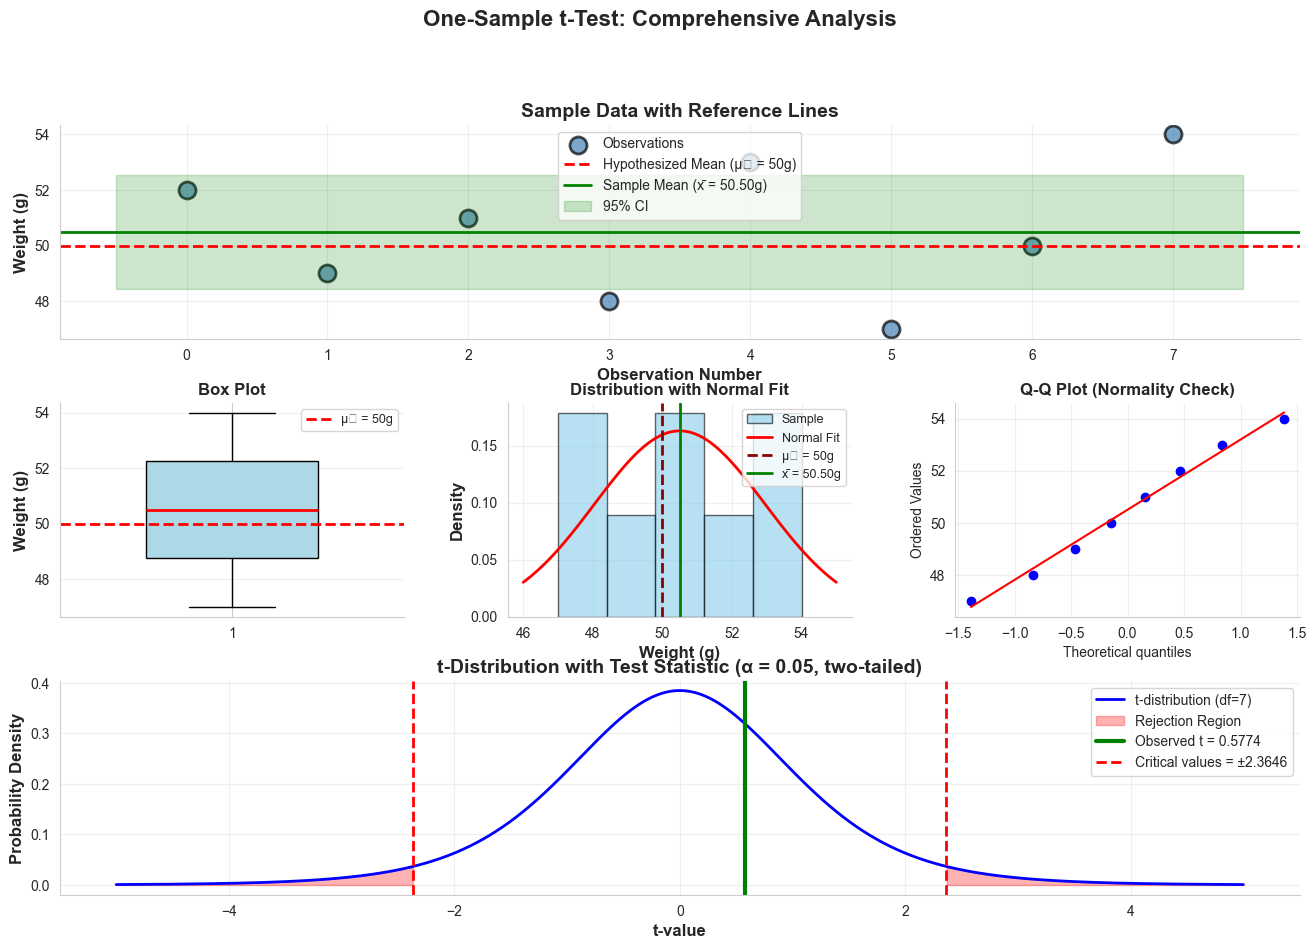

In [10]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Data distribution with reference lines
ax1 = fig.add_subplot(gs[0, :])
x_positions = np.arange(len(weights))
ax1.scatter(x_positions, weights, s=150, alpha=0.7, color="steelblue", edgecolors="black", linewidth=2, label="Observations")
ax1.axhline(y=mu_0, color="red", linestyle="--", linewidth=2, label=f"Hypothesized Mean (μ₀ = {mu_0}g)")
ax1.axhline(y=sample_mean, color="green", linestyle="-", linewidth=2, label=f"Sample Mean (x̄ = {sample_mean:.2f}g)")
ax1.fill_between([-0.5, len(weights)-0.5], ci_lower, ci_upper, alpha=0.2, color="green", label="95% CI")
ax1.set_xlabel("Observation Number", fontsize=12, fontweight="bold")
ax1.set_ylabel("Weight (g)", fontsize=12, fontweight="bold")
ax1.set_title("Sample Data with Reference Lines", fontsize=14, fontweight="bold")
ax1.legend(loc="best", fontsize=10)
ax1.grid(True, alpha=0.3)
sns.despine(ax=ax1)

# Plot 2: Box plot
ax2 = fig.add_subplot(gs[1, 0])
bp = ax2.boxplot(weights, vert=True, patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("lightblue")
bp["boxes"][0].set_edgecolor("black")
bp["medians"][0].set_color("red")
bp["medians"][0].set_linewidth(2)
ax2.axhline(y=mu_0, color="red", linestyle="--", linewidth=2, label=f"μ₀ = {mu_0}g")
ax2.set_ylabel("Weight (g)", fontsize=12, fontweight="bold")
ax2.set_title("Box Plot", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")
sns.despine(ax=ax2)

# Plot 3: Histogram with normal overlay
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(weights, bins=5, density=True, alpha=0.6, color="skyblue", edgecolor="black", label="Sample")
x_range = np.linspace(weights.min() - 1, weights.max() + 1, 100)
normal_curve = stats.norm.pdf(x_range, sample_mean, sample_std)
ax3.plot(x_range, normal_curve, color="red", linewidth=2, label="Normal Fit")
ax3.axvline(x=mu_0, color="darkred", linestyle="--", linewidth=2, label=f"μ₀ = {mu_0}g")
ax3.axvline(x=sample_mean, color="green", linestyle="-", linewidth=2, label=f"x̄ = {sample_mean:.2f}g")
ax3.set_xlabel("Weight (g)", fontsize=12, fontweight="bold")
ax3.set_ylabel("Density", fontsize=12, fontweight="bold")
ax3.set_title("Distribution with Normal Fit", fontsize=12, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
sns.despine(ax=ax3)

# Plot 4: Q-Q plot for normality
ax4 = fig.add_subplot(gs[1, 2])
stats.probplot(weights, dist="norm", plot=ax4)
ax4.set_title("Q-Q Plot (Normality Check)", fontsize=12, fontweight="bold")
ax4.grid(True, alpha=0.3)
sns.despine(ax=ax4)

# Plot 5: t-distribution with test statistic
ax5 = fig.add_subplot(gs[2, :])
t_range = np.linspace(-5, 5, 1000)
t_pdf = stats.t.pdf(t_range, df)
ax5.plot(t_range, t_pdf, color="blue", linewidth=2, label=f"t-distribution (df={df})")
ax5.fill_between(t_range, 0, t_pdf, where=(t_range <= -t_critical), alpha=0.3, color="red", label="Rejection Region")
ax5.fill_between(t_range, 0, t_pdf, where=(t_range >= t_critical), alpha=0.3, color="red")
ax5.axvline(x=t_statistic, color="green", linestyle="-", linewidth=3, label=f"Observed t = {t_statistic:.4f}")
ax5.axvline(x=-t_critical, color="red", linestyle="--", linewidth=2, label=f"Critical values = ±{t_critical:.4f}")
ax5.axvline(x=t_critical, color="red", linestyle="--", linewidth=2)
ax5.set_xlabel("t-value", fontsize=12, fontweight="bold")
ax5.set_ylabel("Probability Density", fontsize=12, fontweight="bold")
ax5.set_title(f"t-Distribution with Test Statistic (α = {alpha}, two-tailed)", fontsize=14, fontweight="bold")
ax5.legend(loc="upper right", fontsize=10)
ax5.grid(True, alpha=0.3)
sns.despine(ax=ax5)

plt.suptitle("One-Sample t-Test: Comprehensive Analysis", fontsize=16, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## Step 9: Complete Summary Report

### Why We Generate a Formal Report:

Professional statistical analysis requires comprehensive documentation that:
1. **Ensures Reproducibility**: Anyone can understand and verify our work
2. **Meets Academic Standards**: Required format for assignments, theses, publications
3. **Supports Decision-Making**: Provides executives/stakeholders with clear conclusions
4. **Creates Permanent Record**: Documents methodology and findings for future reference
5. **Demonstrates Rigor**: Shows we followed proper statistical protocol

### How Our Report is Structured:

**Section 1 - Problem Statement:**
- **Why**: Establishes context and research question
- **What**: Sample size, hypothesized value, significance level
- **For whom**: Ensures readers understand the testing scenario

**Section 2 - Hypotheses:**
- **Why**: Formal statistical statements required for scientific validity
- **What**: H₀ and H₁ with proper notation
- **Note**: Explicitly states "two-tailed" to clarify test type

**Section 3 - Descriptive Statistics:**
- **Why**: Characterizes the sample before inference
- **What**: Mean, SD, SE, confidence interval
- **Use**: Provides context for interpreting test results

**Section 4 - Test Results:**
- **Why**: Core statistical findings in one place
- **What**: t-statistic, df, p-value, critical values, effect size
- **Format**: Follows standard reporting conventions (e.g., "t(7) = X.XX, p = X.XX")

**Section 5 - Assumption Checks:**
- **Why**: Documents validity of test application
- **What**: Normality test results and interpretation
- **Importance**: Critical for trusting conclusions

**Section 6 - Decision & Conclusion:**
- **Statistical Decision**: Reject or fail to reject H₀ (technical)
- **Statistical Conclusion**: Formal statement with test statistics
- **Practical Interpretation**: What it means in plain language
- **Why both**: Bridges statistics and real-world application

**Section 7 - Recommendations:**
- **Why**: Translates statistics to action
- **Quality Control Context**: 
  - If significant → Machine needs calibration
  - If not significant → Continue normal operation
- **Business Value**: Makes statistical analysis actionable

### Report Features:

- **Formatted Headers**: Visual separation of sections
- **Consistent Notation**: Greek letters (μ, α) and statistical symbols
- **Decision Markers**: ✓ and ✗ for quick visual scanning
- **Percentage Calculations**: Shows practical deviation size
- **Professional Tone**: Suitable for technical documentation

This report format is adaptable to any hypothesis test and represents industry/academic best practices for statistical reporting.

In [11]:
print("\n" + "="*80)
print(" "*20 + "COMPLETE STATISTICAL REPORT")
print("="*80)

print(f"\n{'PROBLEM STATEMENT':-^80}")
print(f"Test whether sample mean differs from hypothesized value μ₀ = {mu_0}g")
print(f"Sample: n = {n} weight measurements")
print(f"Significance level: α = {alpha}")

print(f"\n{'HYPOTHESES':-^80}")
print(f"H₀: μ = {mu_0} (true mean equals {mu_0}g)")
print(f"H₁: μ ≠ {mu_0} (true mean differs from {mu_0}g) [Two-tailed]")

print(f"\n{'DESCRIPTIVE STATISTICS':-^80}")
print(f"Sample Mean (x̄):              {sample_mean:.4f} g")
print(f"Sample Std Dev (s):            {sample_std:.4f} g")
print(f"Standard Error (SE):           {standard_error:.4f} g")
print(f"95% CI for μ:                  [{ci_lower:.4f}, {ci_upper:.4f}] g")

print(f"\n{'TEST RESULTS':-^80}")
print(f"t-statistic:                   {t_statistic:.4f}")
print(f"Degrees of freedom:            {df}")
print(f"p-value (two-tailed):          {p_value:.6f}")
print(f"Critical t-values (±):         ±{t_critical:.4f}")
print(f"Cohen's d (effect size):       {cohens_d:.4f} ({effect_interpretation})")

print(f"\n{'ASSUMPTION CHECKS':-^80}")
print(f"Normality (Shapiro-Wilk):      W = {stat_normality:.4f}, p = {p_normality:.4f}")
if p_normality > 0.05:
    print(f"   ✓ Assumption satisfied (data consistent with normal distribution)")
else:
    print(f"   ⚠ Potential violation (consider robust alternatives)")

print(f"\n{'DECISION':-^80}")
if reject_h0_pvalue:
    print(f"✗ REJECT H₀ (p = {p_value:.6f} < α = {alpha})")
    print(f"\nStatistical Conclusion:")
    print(f"   There is statistically significant evidence that the true mean weight")
    print(f"   differs from {mu_0}g, t({df}) = {t_statistic:.4f}, p = {p_value:.4f}.")
    print(f"\nPractical Interpretation:")
    print(f"   The machine is producing items with a mean weight significantly different")
    print(f"   from the claimed {mu_0}g. The sample mean is {sample_mean:.2f}g, which is")
    print(f"   {abs(sample_mean - mu_0):.2f}g {'higher' if sample_mean > mu_0 else 'lower'} than the target.")
    print(f"   This represents a {effect_interpretation} effect (Cohen's d = {cohens_d:.4f}).")
else:
    print(f"✓ FAIL TO REJECT H₀ (p = {p_value:.6f} ≥ α = {alpha})")
    print(f"\nStatistical Conclusion:")
    print(f"   There is insufficient evidence to conclude that the true mean weight")
    print(f"   differs from {mu_0}g, t({df}) = {t_statistic:.4f}, p = {p_value:.4f}.")
    print(f"\nPractical Interpretation:")
    print(f"   The data is consistent with the machine's claim of {mu_0}g mean weight.")
    print(f"   The observed difference ({abs(sample_mean - mu_0):.2f}g) can be attributed to")
    print(f"   random sampling variation rather than systematic deviation.")

print(f"\n{'QUALITY CONTROL RECOMMENDATION':-^80}")
if reject_h0_pvalue:
    print(f"⚠ ACTION REQUIRED: Machine calibration needed")
    print(f"   - Current mean: {sample_mean:.2f}g (Target: {mu_0}g)")
    print(f"   - Deviation: {abs(sample_mean - mu_0):.2f}g ({abs((sample_mean - mu_0)/mu_0 * 100):.2f}%)")
    print(f"   - Recommend recalibration and retesting")
else:
    print(f"✓ Machine performing within acceptable limits")
    print(f"   - Continue regular monitoring")
    print(f"   - Next quality check as scheduled")

print("\n" + "="*80)
print(f" "*25 + "END OF REPORT")
print("="*80)


                    COMPLETE STATISTICAL REPORT

-------------------------------PROBLEM STATEMENT--------------------------------
Test whether sample mean differs from hypothesized value μ₀ = 50g
Sample: n = 8 weight measurements
Significance level: α = 0.05

-----------------------------------HYPOTHESES-----------------------------------
H₀: μ = 50 (true mean equals 50g)
H₁: μ ≠ 50 (true mean differs from 50g) [Two-tailed]

-----------------------------DESCRIPTIVE STATISTICS-----------------------------
Sample Mean (x̄):              50.5000 g
Sample Std Dev (s):            2.4495 g
Standard Error (SE):           0.8660 g
95% CI for μ:                  [48.4522, 52.5478] g

----------------------------------TEST RESULTS----------------------------------
t-statistic:                   0.5774
Degrees of freedom:            7
p-value (two-tailed):          0.581788
Critical t-values (±):         ±2.3646
Cohen's d (effect size):       0.2041 (small)

-------------------------------ASSUMP

## Implementation Summary

### What Was Implemented:

1. **Complete Manual Calculation**:
   - Sample mean, variance, standard deviation
   - Standard error and t-statistic
   - All formulas shown explicitly

2. **Hypothesis Testing Procedure**:
   - Formal hypothesis setup (H₀ and H₁)
   - Two-tailed t-test execution
   - p-value and critical value approaches
   - Effect size calculation (Cohen's d)

3. **Assumption Validation**:
   - Shapiro-Wilk normality test
   - Q-Q plot for visual normality assessment

4. **Verification**:
   - scipy.stats implementation for validation
   - Comparison of manual vs. automated results

5. **Comprehensive Visualization**:
   - Data distribution with reference lines
   - Box plot and histogram
   - Q-Q plot
   - t-distribution with rejection regions

6. **Professional Reporting**:
   - Complete statistical report
   - Quality control recommendations
   - Both statistical and practical interpretations

### Key Learning Outcomes:

- Understanding when to use one-sample t-test
- Manual calculation of test statistics
- Interpretation of p-values and effect sizes
- Importance of assumption checking
- Translating statistical results to practical decisions